### Part 1

#### Subpart 1

In [1]:
# !pip install datasets torchvision torch --quiet  # if needed
import random, numpy as np, torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from datasets import load_dataset
import matplotlib.pyplot as plt
import pandas as pd

# Repro
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
gen_loader = torch.Generator().manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/160255 [00:00<?, ? examples/s]

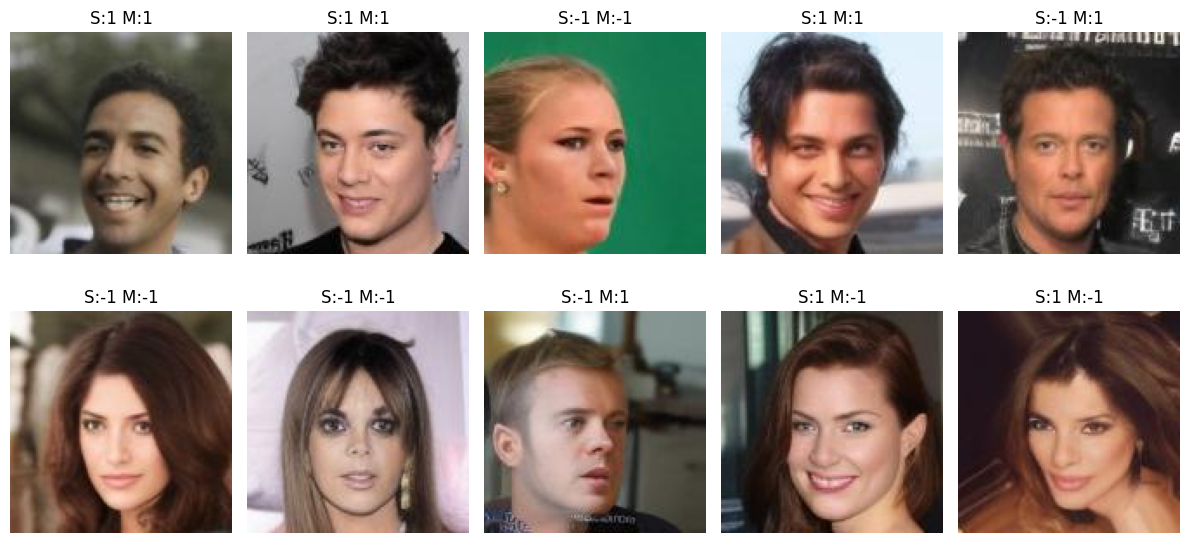

In [2]:
# CelebA artificial attrs (images + attributes)
ds_full = load_dataset("tpremoli/CelebA-attrs-160k-artificial", split="train")

# make a stable index
ds_full = ds_full.add_column("orig_idx", list(range(len(ds_full))))

# quick preview: 10 random samples
sample = ds_full.shuffle(seed=42).select(range(10))
plt.figure(figsize=(12,6))
for i, ex in enumerate(sample):
    ax = plt.subplot(2,5,i+1)
    ax.imshow(ex["image"])
    ax.set_axis_off()
    ax.set_title(f"S:{ex['Smiling']} M:{ex['Male']}")
plt.tight_layout(); plt.show()


#### Subpart 2

In [3]:
# Work with a tiny attrs table for splitting
attrs = ds_full.remove_columns([c for c in ds_full.column_names if c not in ["orig_idx","Smiling","Male"]]).to_pandas()

# Make sure labels are 0/1 (dataset is already 0/1, but sanitize anyway)
attrs["Smiling"] = attrs["Smiling"].map(lambda v: 1 if int(v)==1 else 0)
attrs["Male"]    = attrs["Male"].map(lambda v: 1 if int(v)==1 else 0)

N_CLASS, N_GAN, N_TEST = 4000, 4000, 2000
ratio_plan = {(1,1):0.15, (1,0):0.45, (0,1):0.20, (0,0):0.20}
order = [(1,1),(1,0),(0,1),(0,0)]

# Availability per stratum
avail = attrs.groupby(["Smiling","Male"])["orig_idx"].count()
for k in order:
    if k not in avail: avail.loc[k] = 0
avail = avail.astype(int).sort_index()

# target counts
targets = {k:int(round(ratio_plan[k]*N_CLASS)) for k in order}
# ensure exact sum
diff = N_CLASS - sum(targets.values())
for k,_ in sorted(ratio_plan.items(), key=lambda kv: kv[1], reverse=True):
    if diff==0: break
    targets[k] += 1 if diff>0 else -1
    diff += -1 if diff>0 else 1

# allocator under capacity with proportional redistribution
def allocate_under_caps(total, ratios, caps, order):
    remaining = total
    alloc = {k:0 for k in order}
    weights = np.array([ratios[k] for k in order], float)
    if weights.sum()==0: weights = np.ones_like(weights)
    weights /= weights.sum()
    caps = caps.copy()

    while remaining>0:
        active = [k for k in order if caps.get(k,0)>0]
        if not active: break
        a_idx = [order.index(k) for k in active]
        aw = weights[a_idx]
        aw = aw/aw.sum() if aw.sum()>0 else np.ones_like(aw)/len(aw)
        chunk = max(remaining//3, 1)
        proposal = np.floor(aw*chunk).astype(int)
        if proposal.sum()==0: proposal[np.random.RandomState(SEED).randint(0,len(proposal))]=1
        placed = 0
        for j,k in enumerate(active):
            take = min(int(proposal[j]), caps[k], remaining)
            if take>0:
                alloc[k]+=take; caps[k]-=take; remaining-=take; placed+=take
        if placed==0:
            for k in active:
                if remaining==0: break
                if caps[k]>0:
                    alloc[k]+=1; caps[k]-=1; remaining-=1
    return alloc

allocated = allocate_under_caps(N_CLASS, ratio_plan, avail.to_dict(), order)

# sample classifier indices
rng = np.random.RandomState(SEED)
def sample_from_stratum(df, s, m, n):
    pool = df[(df["Smiling"]==s) & (df["Male"]==m)]["orig_idx"].values
    n = min(n, len(pool))
    return rng.choice(pool, size=n, replace=False).tolist()

classifier_idx = []
for (s,m) in order:
    n = allocated[(s,m)]
    classifier_idx += sample_from_stratum(attrs, s, m, n)

# remaining pool
remaining = set(attrs["orig_idx"].tolist()) - set(classifier_idx)
gan_idx  = set(rng.choice(list(remaining), size=N_GAN, replace=False).tolist())
remaining -= gan_idx
test_idx = set(rng.choice(list(remaining), size=N_TEST, replace=False).tolist())

# build HF splits (with images)
pos = pd.Series(range(len(ds_full)), index=ds_full["orig_idx"])
classifier_ds = ds_full.select([pos[i] for i in sorted(classifier_idx)])
gan_ds        = ds_full.select([pos[i] for i in sorted(gan_idx)])
test_ds       = ds_full.select([pos[i] for i in sorted(test_idx)])

# quick stats
def ctab(ds, name):
    df = ds.remove_columns([c for c in ds.column_names if c not in ["Smiling","Male"]]).to_pandas()
    print(f"\n{name} size: {len(df)}")
    print(pd.crosstab(df["Smiling"], df["Male"], normalize="all").round(3))
ctab(classifier_ds,"Classifier"); ctab(gan_ds,"GAN"); ctab(test_ds,"Test")



Classifier size: 4000
Male        -1      1
Smiling              
-1       0.200  0.202
 1       0.451  0.148

GAN size: 4000
Male        -1      1
Smiling              
-1       0.267  0.254
 1       0.316  0.162

Test size: 2000
Male        -1      1
Smiling              
-1       0.282  0.246
 1       0.298  0.174


### Part 2

In [4]:
# Torch dataset wrapper
class HFDataset(Dataset):
    def __init__(self, hf_ds, transform, label="Smiling"):
        self.ds, self.t, self.label = hf_ds, transform, label
    def __len__(self): return len(self.ds)
    def __getitem__(self, i):
        item = self.ds[i]
        x = self.t(item["image"].convert("RGB"))
        y = 1 if int(item[self.label])==1 else 0
        return x, torch.tensor(y, dtype=torch.long)

img_size=224
train_tfms = transforms.Compose([
    transforms.Resize((img_size,img_size)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3,[0.5]*3),
])
test_tfms = transforms.Compose([
    transforms.Resize((img_size,img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3,[0.5]*3),
])

train_torch = HFDataset(classifier_ds, train_tfms, "Smiling")
test_torch  = HFDataset(test_ds,       test_tfms,  "Smiling")

BATCH=64
train_loader = DataLoader(train_torch, batch_size=BATCH, shuffle=True,
                          generator=gen_loader, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_torch,  batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)

# Model
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 2)
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
EPOCHS=10

losses, accs = [], []
for ep in range(1,EPOCHS+1):
    model.train()
    L=A=0.0; steps=0
    for x,y in train_loader:
        x,y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad()
        out = model(x); loss = criterion(out,y)
        loss.backward(); optimizer.step()
        L += loss.item()
        A += (out.argmax(1)==y).float().mean().item()
        steps += 1
    losses.append(L/steps); accs.append(A/steps)
    print(f"Epoch {ep:02d}/{EPOCHS} | Loss:{losses[-1]:.4f} | Acc:{accs[-1]*100:.2f}%")


Epoch 01/10 | Loss:0.4645 | Acc:77.48%
Epoch 02/10 | Loss:0.2709 | Acc:88.94%
Epoch 03/10 | Loss:0.2211 | Acc:91.17%
Epoch 04/10 | Loss:0.2009 | Acc:92.63%
Epoch 05/10 | Loss:0.1749 | Acc:92.96%
Epoch 06/10 | Loss:0.1470 | Acc:94.52%
Epoch 07/10 | Loss:0.1362 | Acc:94.74%
Epoch 08/10 | Loss:0.1300 | Acc:94.87%
Epoch 09/10 | Loss:0.1092 | Acc:95.93%
Epoch 10/10 | Loss:0.1029 | Acc:96.11%


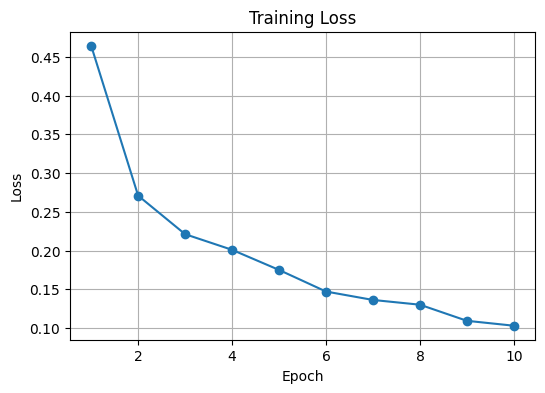

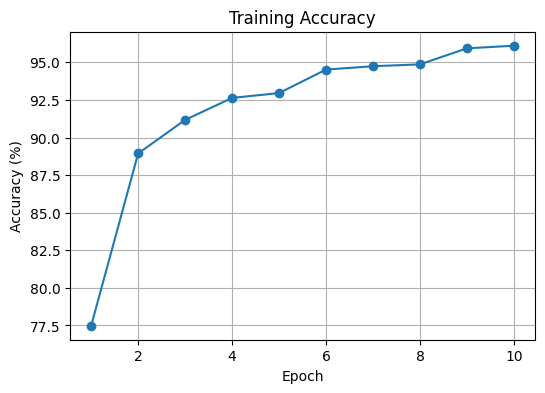

Test Accuracy: 0.8965 on 2000 samples


In [5]:

# plots
plt.figure(figsize=(6,4)); plt.plot(range(1,EPOCHS+1), losses, marker='o')
plt.title("Training Loss"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.grid(True); plt.show()
plt.figure(figsize=(6,4)); plt.plot(range(1,EPOCHS+1), [a*100 for a in accs], marker='o')
plt.title("Training Accuracy"); plt.xlabel("Epoch"); plt.ylabel("Accuracy (%)"); plt.grid(True); plt.show()

# test accuracy
model.eval(); correct=total=0
with torch.no_grad():
    for x,y in test_loader:
        x,y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        pred = model(x).argmax(1)
        correct += (pred==y).sum().item(); total += y.size(0)
print(f"Test Accuracy: {correct/total:.4f} on {total} samples")

# save to reuse in FAAP
torch.save(model.state_dict(), "smile_resnet18_scratch.pt")


### Part 3

In [6]:
# Dataset for GAN (needs both y and z)
class GANSet(Dataset):
    def __init__(self, hf_ds, transform):
        self.ds, self.t = hf_ds, transform
    def __len__(self): return len(self.ds)
    def __getitem__(self, i):
        it = self.ds[i]
        x = self.t(it["image"].convert("RGB"))
        y = 1 if int(it["Smiling"])==1 else 0
        z = 1 if int(it["Male"])==1 else 0
        return x, torch.tensor(y, dtype=torch.long), torch.tensor(z, dtype=torch.long)

gan_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3,[0.5]*3),
])
gan_torch = GANSet(gan_ds, gan_tfms)
gan_loader = DataLoader(gan_torch, batch_size=64, shuffle=True,
                        generator=gen_loader, num_workers=2, pin_memory=True, drop_last=True)

# load the trained base model & freeze
base = models.resnet18(weights=None); base.fc = nn.Linear(base.fc.in_features, 2)
base.load_state_dict(torch.load("smile_resnet18_scratch.pt", map_location="cpu"))
base.to(device).eval()
for p in base.parameters(): p.requires_grad=False


In [30]:

# feature extractor (to 512) & label head
class Feat(nn.Module):
    def __init__(self, r):
        super().__init__()
        self.stem = nn.Sequential(r.conv1,r.bn1,r.relu,r.maxpool,r.layer1,r.layer2,r.layer3,r.layer4)
        self.pool = nn.AdaptiveAvgPool2d((1,1))
    def forward(self,x): return self.pool(self.stem(x)).flatten(1)
class Head(nn.Module):
    def __init__(self, r): super().__init__(); self.fc = r.fc
    def forward(self,r): return self.fc(r)

g = Feat(base).eval().to(device); f = Head(base).eval().to(device)
for p in g.parameters(): p.requires_grad=False
for p in f.parameters(): p.requires_grad=False

# Generator / Discriminator per your tables
class Generator(nn.Module):
    def __init__(self, eps=0.05):
        super().__init__()
        self.eps = eps
        self.down = nn.Sequential(
            nn.Conv2d(3,32,4,2,1,bias=False), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.Conv2d(32,64,4,2,1,bias=False), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.Conv2d(64,128,4,2,1,bias=False), nn.BatchNorm2d(128), nn.ReLU(True),
        )
        self.up = nn.Sequential(
            nn.ConvTranspose2d(128,64,4,2,1,bias=False), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.ConvTranspose2d(64,32,4,2,1,bias=False),  nn.BatchNorm2d(32), nn.ReLU(True),
            nn.ConvTranspose2d(32,3,4,2,1,bias=True), nn.Tanh(),
        )
    def forward(self, x):
        d = self.up(self.down(x))
        d = torch.clamp(d, -self.eps, self.eps)     # ε = 0.05 (fixed)
        x_hat = torch.clamp(x + d, -1, 1)
        return x_hat, d

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(512,128), nn.ReLU(True), nn.Linear(128,2))
    def forward(self, r): return self.net(r)

EPS=0.05
G, D = Generator(EPS).to(device), Discriminator().to(device)
optG = torch.optim.Adam(G.parameters(), lr=1e-4)
optD = torch.optim.Adam(D.parameters(), lr=1e-4)
ce = nn.CrossEntropyLoss()

# tune these (not epsilon): higher alpha → more fairness pressure; higher beta → preserve task more
alpha, beta = 0.4, 0.6

def entropy_from_logits(logits):
    p = torch.softmax(logits, dim=1).clamp_min(1e-8)
    return (-p*p.log()).sum(1).mean()

EPOCHS=10
D_hist, G_hist, Fool_hist = [], [], []

for ep in range(1,EPOCHS+1):
    G.train(); D.train()
    dsum=gsum=asum=0.0; steps=0
    for x,y,z in gan_loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True).long().clamp_(0,1)
        z = z.to(device, non_blocking=True).long().clamp_(0,1)

        # --- D step ---
        with torch.no_grad():
            x_hat,_ = G(x); r_hat = g(x_hat)
        logits_z = D(r_hat)
        loss_D = ce(logits_z, z)
        optD.zero_grad(); loss_D.backward(); optD.step()
        with torch.no_grad():
            acc_D = (logits_z.argmax(1)==z).float().mean().item()
            fool = 1.0 - acc_D

        # --- G step ---
        x_hat,_ = G(x); r_hat = g(x_hat)
        logits_z2 = D(r_hat)
        logits_y  = f(r_hat)
        loss_fair = -ce(logits_z2, z) - alpha*entropy_from_logits(logits_z2)
        loss_task =  ce(logits_y,  y)
        loss_G = loss_fair + beta*loss_task
        optG.zero_grad(); loss_G.backward(); optG.step()

        dsum+=loss_D.item(); gsum+=loss_G.item(); asum+=fool; steps+=1

    D_hist.append(dsum/steps); G_hist.append(gsum/steps); Fool_hist.append(asum/steps)
    print(f"Epoch {ep:02d}/{EPOCHS} | D:{D_hist[-1]:.4f} | G:{G_hist[-1]:.4f} | FoolAcc:{Fool_hist[-1]*100:.2f}%")


Epoch 01/10 | D:0.6518 | G:-0.7232 | FoolAcc:38.99%
Epoch 02/10 | D:0.6433 | G:-0.7230 | FoolAcc:37.00%
Epoch 03/10 | D:0.6408 | G:-0.7269 | FoolAcc:37.22%
Epoch 04/10 | D:0.6404 | G:-0.7324 | FoolAcc:37.12%
Epoch 05/10 | D:0.6340 | G:-0.7296 | FoolAcc:35.41%
Epoch 06/10 | D:0.6352 | G:-0.7326 | FoolAcc:35.13%
Epoch 07/10 | D:0.6315 | G:-0.7353 | FoolAcc:35.18%
Epoch 08/10 | D:0.6336 | G:-0.7351 | FoolAcc:35.21%
Epoch 09/10 | D:0.6282 | G:-0.7338 | FoolAcc:34.53%
Epoch 10/10 | D:0.6281 | G:-0.7318 | FoolAcc:33.97%


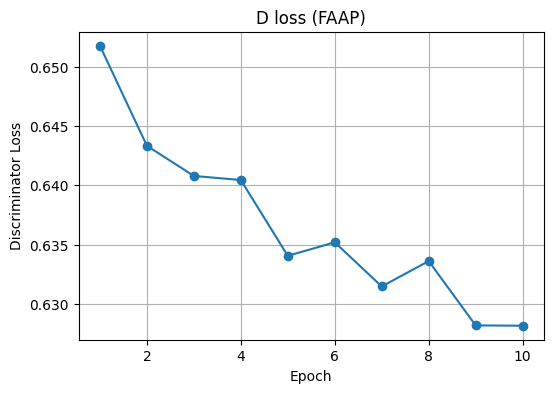

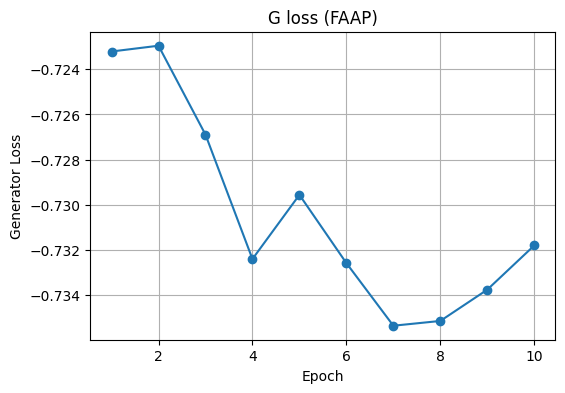

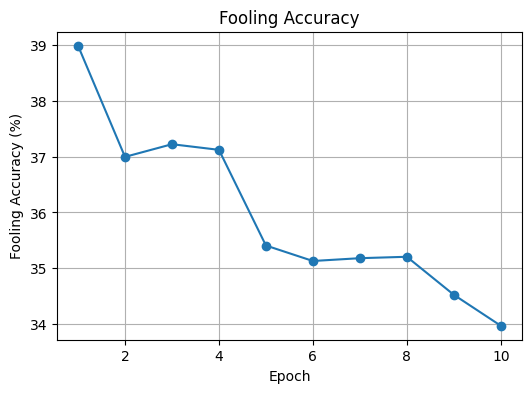

In [31]:

# plots
plt.figure(figsize=(6,4)); plt.plot(range(1,EPOCHS+1), D_hist, marker='o'); plt.grid(True)
plt.xlabel("Epoch"); plt.ylabel("Discriminator Loss"); plt.title("D loss (FAAP)"); plt.show()
plt.figure(figsize=(6,4)); plt.plot(range(1,EPOCHS+1), G_hist, marker='o'); plt.grid(True)
plt.xlabel("Epoch"); plt.ylabel("Generator Loss"); plt.title("G loss (FAAP)"); plt.show()
plt.figure(figsize=(6,4)); plt.plot(range(1,EPOCHS+1), [a*100 for a in Fool_hist], marker='o'); plt.grid(True)
plt.xlabel("Epoch"); plt.ylabel("Fooling Accuracy (%)"); plt.title("Fooling Accuracy"); plt.show()


Baseline test accuracy (original): 0.8965
FAAP test accuracy (perturbed):   0.9090


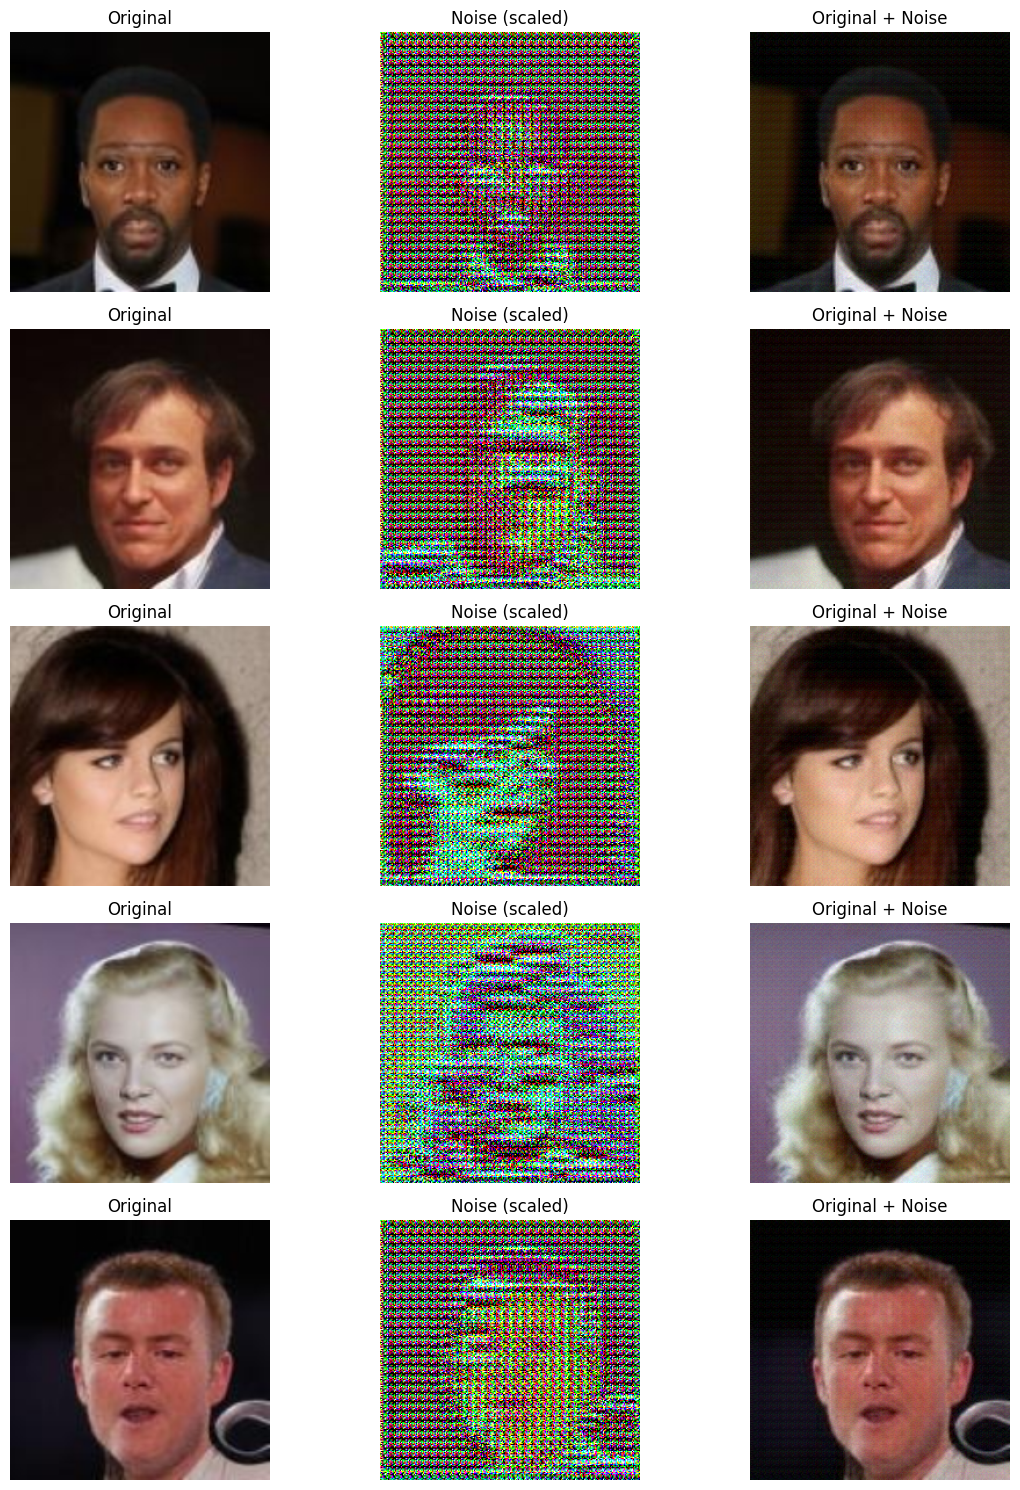

In [32]:
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import numpy as np
import random

# -----------------------------
# Helpers
# -----------------------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

def denorm(img_t):
    # img_t in [-1,1] -> [0,1] for display
    return torch.clamp((img_t * 0.5) + 0.5, 0.0, 1.0)

def noise_to_vis(d, eps):
    # d in [-eps, eps] -> [0,1] for display, centered at 0.5
    return torch.clamp(0.5 + d / (2*eps), 0.0, 1.0)

# Re-wrap test split if needed
class TestSet(Dataset):
    def __init__(self, hf_ds, transform):
        self.ds, self.t = hf_ds, transform
    def __len__(self): return len(self.ds)
    def __getitem__(self, i):
        item = self.ds[i]
        x = self.t(item["image"].convert("RGB"))
        y = 1 if int(item["Smiling"])==1 else 0
        return x, torch.tensor(y, dtype=torch.long)

# Use the same normalization as training ([-1,1])
test_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3,[0.5]*3),
])

test_torch = TestSet(test_ds, test_tfms)
test_loader = DataLoader(test_torch, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

# -----------------------------
# (1) Accuracy on test: baseline vs FAAP-perturbed
# -----------------------------
g.eval(); f.eval(); G.eval()
device = next(f.parameters()).device

baseline_correct = 0
faap_correct = 0
total = 0

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        # baseline
        r = g(x)
        logits = f(r)
        pred = logits.argmax(1)
        baseline_correct += (pred == y).sum().item()

        # FAAP perturbed
        x_hat, _ = G(x)
        r_hat = g(x_hat)
        logits_hat = f(r_hat)
        pred_hat = logits_hat.argmax(1)
        faap_correct += (pred_hat == y).sum().item()

        total += y.size(0)

baseline_acc = baseline_correct / total
faap_acc = faap_correct / total
print(f"Baseline test accuracy (original): {baseline_acc:.4f}")
print(f"FAAP test accuracy (perturbed):   {faap_acc:.4f}")

# -----------------------------
# (2) Visualize 5 samples: original, noise, perturbed
# -----------------------------
# pick 5 deterministic indices
idxs = list(range(len(test_torch)))
random.Random(SEED).shuffle(idxs)
idxs = idxs[:5]

# build a small batch so we only do one forward pass
batch_x = []
for i in idxs:
    x_i, _ = test_torch[i]
    batch_x.append(x_i)
batch_x = torch.stack(batch_x, dim=0).to(device)

with torch.no_grad():
    x_hat, d = G(batch_x)

# plot per image
cols = 3
rows = len(idxs)
plt.figure(figsize=(cols*4, rows*3))
for i in range(rows):
    # original
    plt.subplot(rows, cols, i*cols + 1)
    plt.imshow(denorm(batch_x[i]).permute(1,2,0).cpu().numpy())
    plt.axis('off'); plt.title("Original")

    # noise
    plt.subplot(rows, cols, i*cols + 2)
    plt.imshow(noise_to_vis(d[i], EPS).permute(1,2,0).cpu().numpy())
    plt.axis('off'); plt.title("Noise (scaled)")

    # perturbed
    plt.subplot(rows, cols, i*cols + 3)
    plt.imshow(denorm(x_hat[i]).permute(1,2,0).cpu().numpy())
    plt.axis('off'); plt.title("Original + Noise")

plt.tight_layout()
plt.show()


### Part 4


Fairness Metrics (Test Set):
            Accuracy  DP diff  EO diff
Base Model     0.896    0.153    0.099
FAAP Model     0.909    0.125    0.073


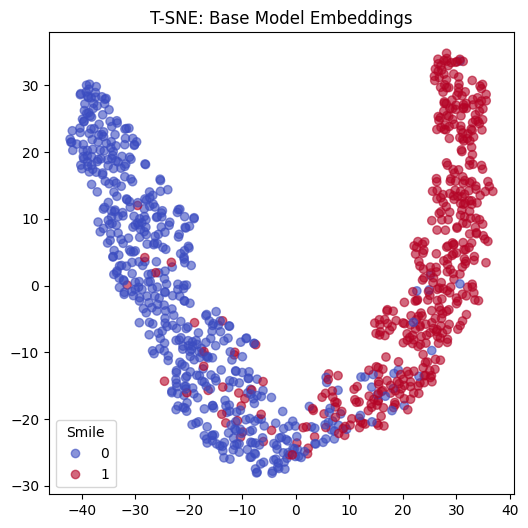

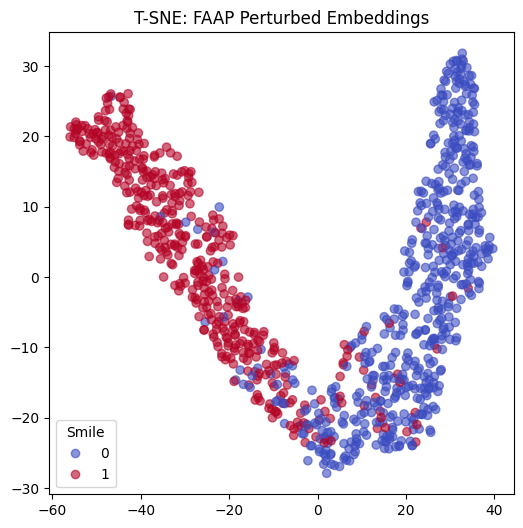

In [33]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import random

# -----------------------------
# Config
# -----------------------------
SEED = 42
BATCH_SIZE = 64
EPS = 0.05  # your FAAP epsilon

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# -----------------------------
# Dataset wrapper (returns smile, gender)
# -----------------------------
test_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

class CelebATest(Dataset):
    def __init__(self, hf_ds, transform):
        self.ds = hf_ds
        self.t = transform
    def __len__(self):
        return len(self.ds)
    def __getitem__(self, idx):
        item = self.ds[idx]
        img = self.t(item["image"].convert("RGB"))
        smile = 1 if int(item["Smiling"]) == 1 else 0
        male  = 1 if int(item["Male"]) == 1 else 0
        return img, torch.tensor(smile, dtype=torch.long), torch.tensor(male, dtype=torch.long)

test_dataset = CelebATest(test_ds, test_tfms)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# -----------------------------
# Fairness metric helper
# -----------------------------
def fairness_metrics(y_true, y_pred, sensitive_attr):
    acc = accuracy_score(y_true, y_pred)

    # Demographic Parity diff
    p_pos_group0 = np.mean(y_pred[sensitive_attr == 0])
    p_pos_group1 = np.mean(y_pred[sensitive_attr == 1])
    dp_diff = abs(p_pos_group0 - p_pos_group1)

    # Equal Opportunity diff
    mask_pos = (y_true == 1)
    tpr_group0 = np.mean(y_pred[(sensitive_attr == 0) & mask_pos])
    tpr_group1 = np.mean(y_pred[(sensitive_attr == 1) & mask_pos])
    eo_diff = abs(tpr_group0 - tpr_group1)

    return acc, dp_diff, eo_diff

# -----------------------------
# Batched evaluation for base and FAAP
# -----------------------------
def get_predictions(loader, perturb_fn=None):
    g.eval(); f.eval()
    all_preds, all_labels, all_attrs = [], [], []
    with torch.no_grad():
        for x, y, a in loader:
            x = x.to(device, non_blocking=True)
            if perturb_fn is not None:
                x = perturb_fn(x)
            r = g(x)
            logits = f(r)
            preds = logits.argmax(1).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(y.numpy())
            all_attrs.append(a.numpy())
    return (np.concatenate(all_preds),
            np.concatenate(all_labels),
            np.concatenate(all_attrs))

# base model predictions
y_pred_base, y_true, a_true = get_predictions(test_loader)

# FAAP predictions
y_pred_faap, _, _ = get_predictions(test_loader, perturb_fn=lambda xb: G(xb)[0])

# -----------------------------
# Compute metrics
# -----------------------------
acc_base, dp_base, eo_base = fairness_metrics(y_true, y_pred_base, a_true)
acc_faap, dp_faap, eo_faap = fairness_metrics(y_true, y_pred_faap, a_true)

results_df = pd.DataFrame({
    "Accuracy": [acc_base, acc_faap],
    "DP diff": [dp_base, dp_faap],
    "EO diff": [eo_base, eo_faap]
}, index=["Base Model", "FAAP Model"]).round(3)

print("\nFairness Metrics (Test Set):")
print(results_df)

# -----------------------------
# T-SNE visualization
# -----------------------------
def get_embeddings(loader, perturb_fn=None):
    g.eval()
    all_emb, all_labels = [], []
    with torch.no_grad():
        for x, y, _ in loader:
            x = x.to(device, non_blocking=True)
            if perturb_fn is not None:
                x = perturb_fn(x)
            r = g(x)
            all_emb.append(r.cpu())
            all_labels.append(y)
    emb = torch.cat(all_emb).numpy()
    labels = torch.cat(all_labels).numpy()
    return emb, labels

# embeddings before and after
emb_base, labels_base = get_embeddings(test_loader)
emb_faap, labels_faap = get_embeddings(test_loader, perturb_fn=lambda xb: G(xb)[0])

# optional: subsample for plotting
max_points = 1000
if len(emb_base) > max_points:
    idx_sub = np.random.RandomState(SEED).choice(len(emb_base), size=max_points, replace=False)
    emb_base = emb_base[idx_sub]
    labels_base = labels_base[idx_sub]
    emb_faap = emb_faap[idx_sub]
    labels_faap = labels_faap[idx_sub]

# run TSNE
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, init="pca")
emb_base_2d = tsne.fit_transform(emb_base)
emb_faap_2d = tsne.fit_transform(emb_faap)

def plot_tsne(emb_2d, labels, title):
    plt.figure(figsize=(6,6))
    scatter = plt.scatter(emb_2d[:,0], emb_2d[:,1], c=labels, cmap="coolwarm", alpha=0.6)
    plt.legend(*scatter.legend_elements(), title="Smile", loc="best")
    plt.title(title)
    plt.show()

plot_tsne(emb_base_2d, labels_base, "T-SNE: Base Model Embeddings")
plot_tsne(emb_faap_2d, labels_faap, "T-SNE: FAAP Perturbed Embeddings")
